
ANALİZ: Breast Cancer


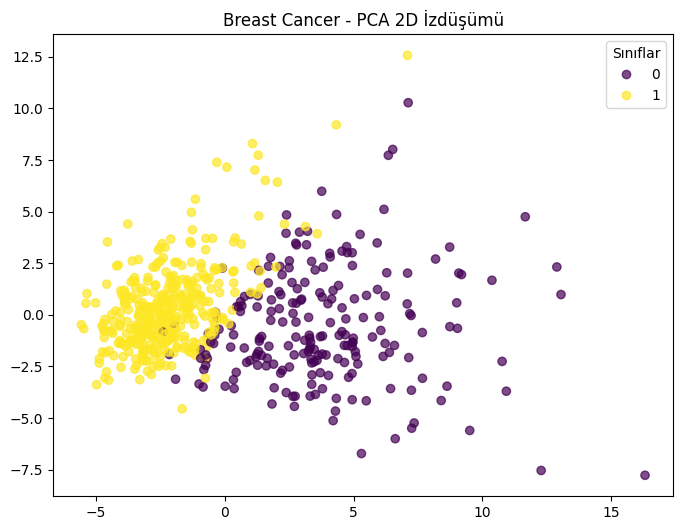

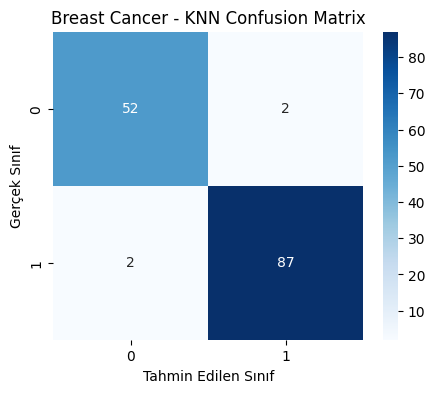

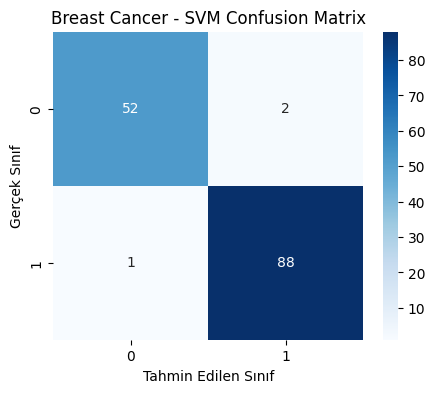

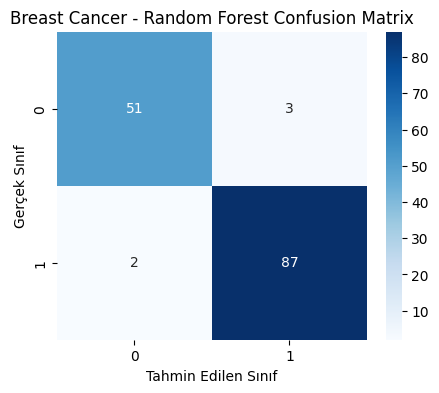


ANALİZ: Wine


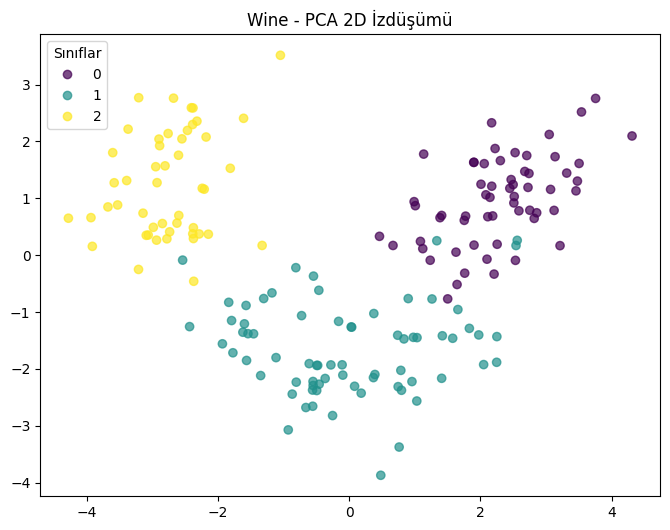

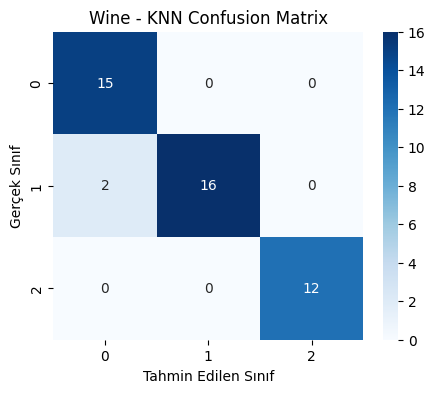

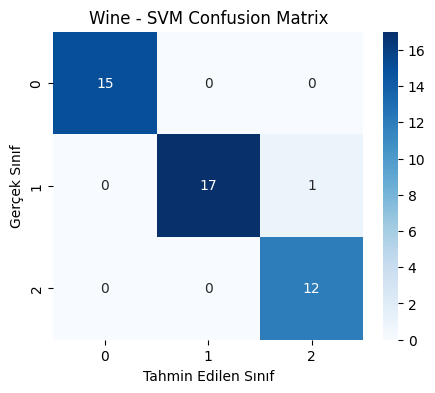

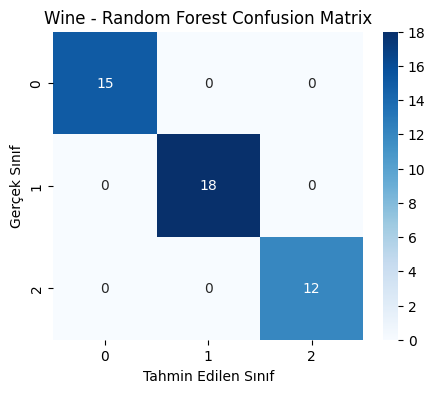


ANALİZ: Digits


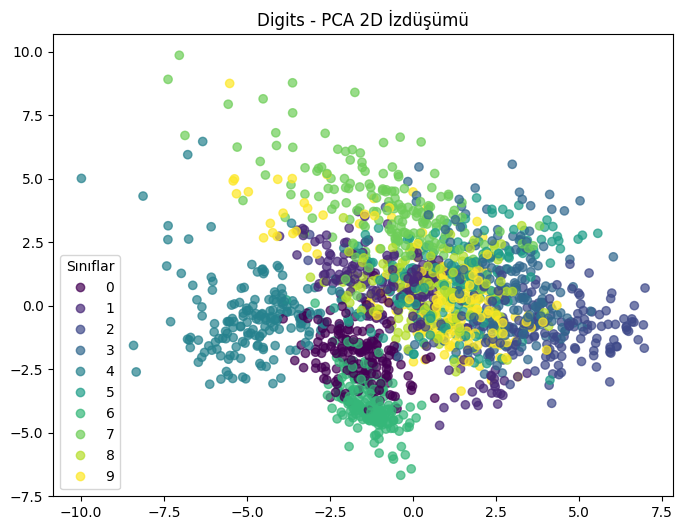

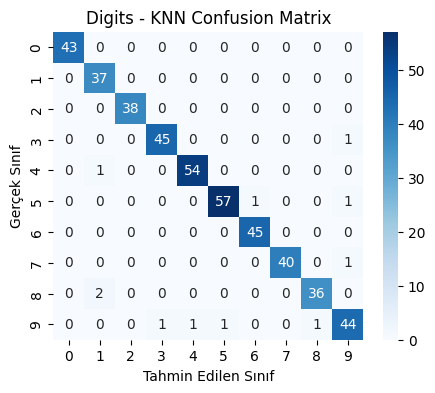

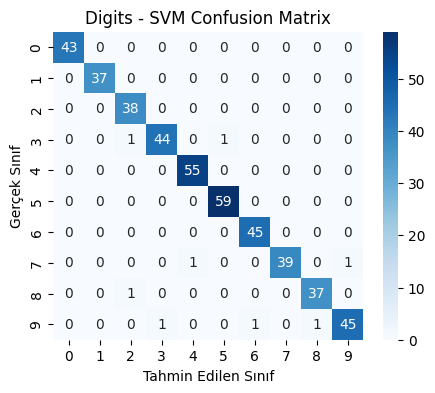

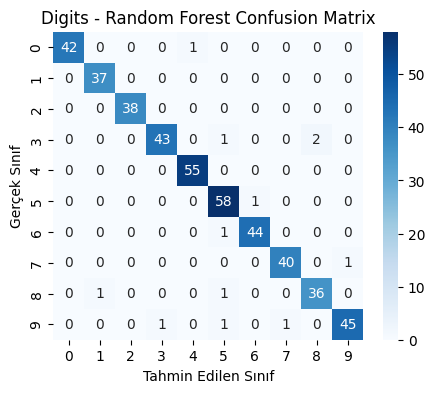

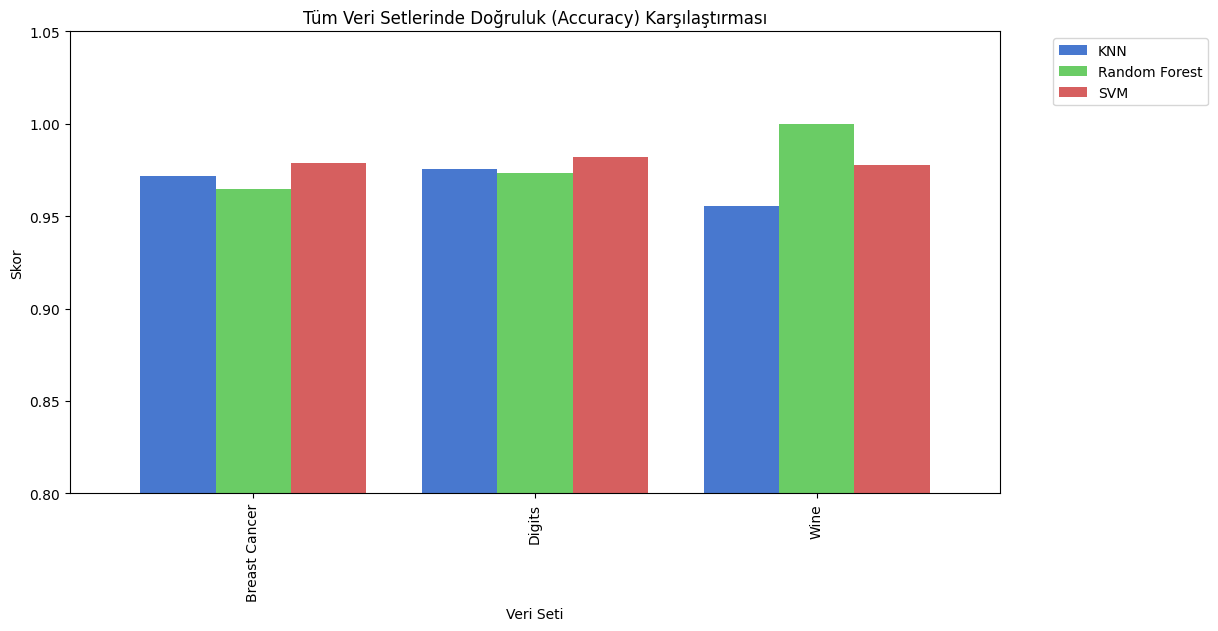

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_wine, load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.decomposition import PCA

# 1. Veri Setlerini Yükleme
datasets = {
    "Breast Cancer": load_breast_cancer(),
    "Wine": load_wine(),
    "Digits": load_digits()
}

# 2. Hiperparametre Uzayları
param_grids = {
    "KNN": {
        'n_neighbors': [3, 5, 7, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    "SVM": {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear']
    },
    "Random Forest": {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'random_state': [42]
    }
}

full_results = []

for ds_name, ds in datasets.items():
    print(f"\n{'='*40}\nANALİZ: {ds_name}\n{'='*40}")
    X, y = ds.data, ds.target
    
    # --- GÖRSELLEŞTİRME 1: Korelasyon Matrisi ---
   ##  plt.figure(figsize=(10, 8))
    ##df_corr = pd.DataFrame(X).corr()
    ## sns.heatmap(df_corr, cmap='coolwarm', center=0, annot=False)
    ## plt.title(f"{ds_name} - Özellik Korelasyon Matrisi")
    ## plt.show() 

    # --- GÖRSELLEŞTİRME 2: PCA ile 2D Veri Dağılımı ---
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(StandardScaler().fit_transform(X))
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
    plt.legend(*scatter.legend_elements(), title="Sınıflar")
    plt.title(f"{ds_name} - PCA 2D İzdüşümü")
    plt.show()

    # Veri Bölme ve Ölçeklendirme
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    for model_name, grid in param_grids.items():
        if model_name == "Random Forest":
            clf = GridSearchCV(RandomForestClassifier(), grid, cv=5)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
        else:
            clf = GridSearchCV(KNeighborsClassifier() if model_name == "KNN" else SVC(), grid, cv=5)
            clf.fit(X_train_sc, y_train)
            y_pred = clf.predict(X_test_sc)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        full_results.append({
            "Veri Seti": ds_name, "Algoritma": model_name,
            "Accuracy": round(acc, 4), "F1-Score": round(f1, 4)
        })
        
        # --- GÖRSELLEŞTİRME 3: Hata Matrisi (Confusion Matrix) ---
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"{ds_name} - {model_name} Confusion Matrix")
        plt.ylabel('Gerçek Sınıf')
        plt.xlabel('Tahmin Edilen Sınıf')
        plt.show()

# 4. Final Karşılaştırma Grafiği
df_results = pd.DataFrame(full_results)
pivot_table = df_results.pivot(index="Veri Seti", columns="Algoritma", values="Accuracy")
ax = pivot_table.plot(kind="bar", figsize=(12, 6), width=0.8)
plt.title("Tüm Veri Setlerinde Doğruluk (Accuracy) Karşılaştırması")
plt.ylabel("Skor")
plt.ylim(0.8, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


ANALİZ: Breast Cancer


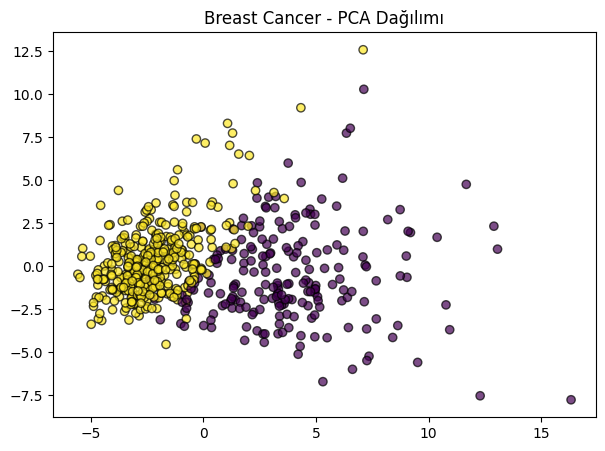

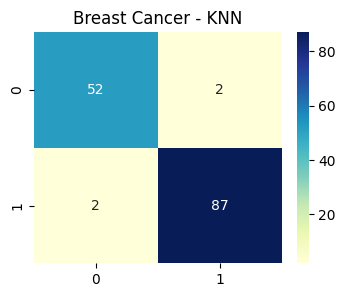

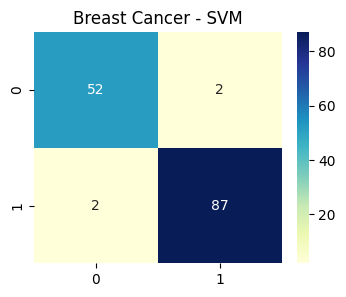

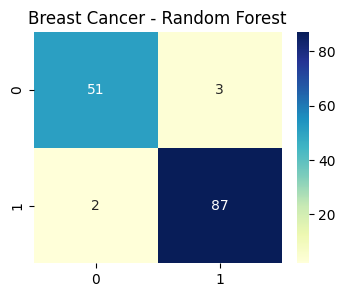


ANALİZ: Wine


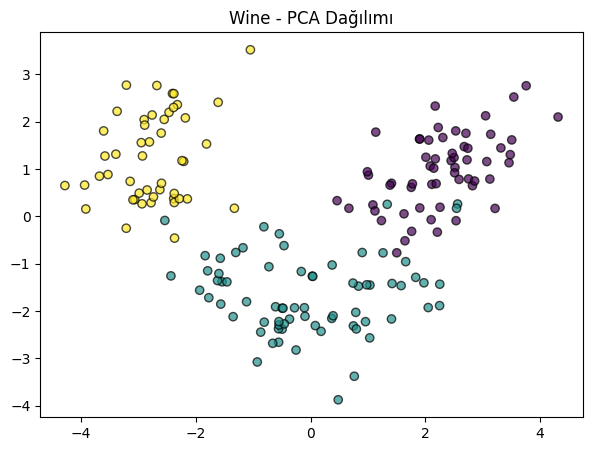

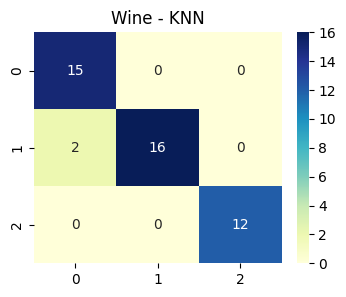

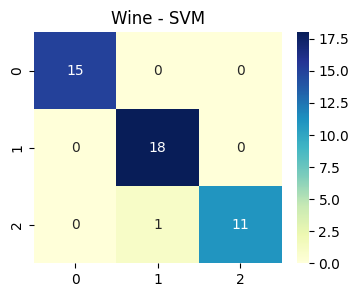

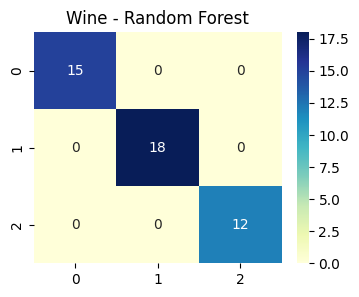


ANALİZ: Moons (Kıvrımlı Yapı)


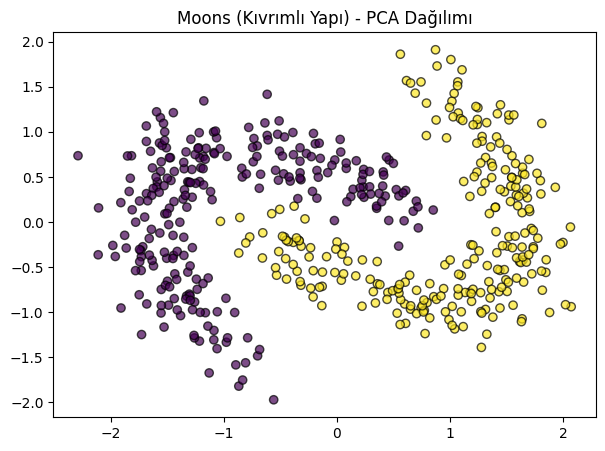

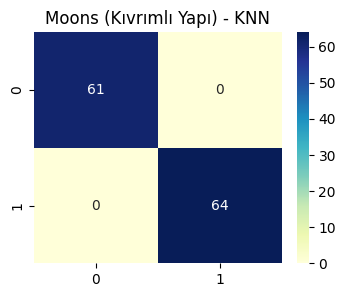

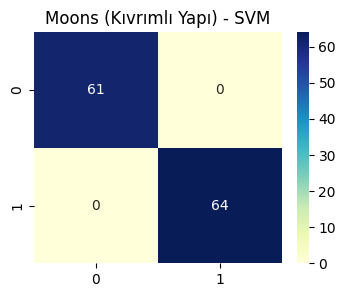

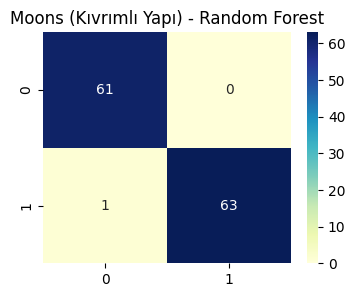

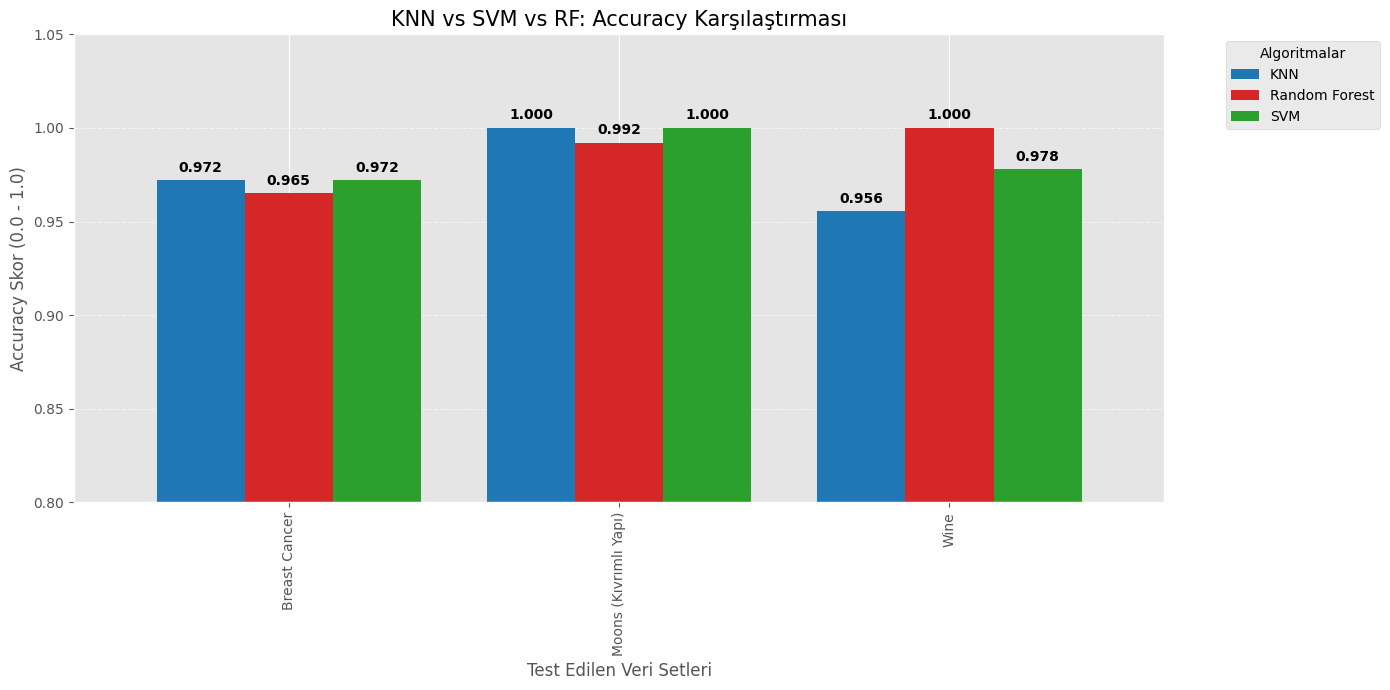

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_wine, make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

# 1. Veri Setlerini Hazırlama
datasets = {
    "Breast Cancer": load_breast_cancer(),
    "Wine": load_wine(),
    "Moons (Kıvrımlı Yapı)": make_moons(n_samples=500, noise=0.15, random_state=42)
}

param_grids = {
    "KNN": {'n_neighbors': [3, 5, 7, 11], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']},
    "SVM": {'C': [0.1, 1, 10], 'kernel': ['rbf', 'poly']},
    "Random Forest": {'n_estimators': [100, 200], 'random_state': [42]}
}

full_results = []

for ds_name, ds in datasets.items():
    print(f"\n{'='*40}\nANALİZ: {ds_name}\n{'='*40}")
    X, y = (ds if isinstance(ds, tuple) else (ds.data, ds.target))
    
    # --- GÖRSELLEŞTİRME 1: PCA 2D İzdüşümü ---
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(StandardScaler().fit_transform(X))
    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7, edgecolors='k')
    plt.title(f"{ds_name} - PCA Dağılımı")
    plt.show()

    # Veri Bölme ve Ölçeklendirme [cite: 101-104]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    for model_name, grid in param_grids.items():
        if model_name == "Random Forest":
            clf = GridSearchCV(RandomForestClassifier(), grid, cv=5)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
        else:
            clf = GridSearchCV(KNeighborsClassifier() if model_name == "KNN" else SVC(), grid, cv=5)
            clf.fit(X_train_sc, y_train)
            y_pred = clf.predict(X_test_sc)
        
        acc = accuracy_score(y_test, y_pred)
        full_results.append({"Veri Seti": ds_name, "Algoritma": model_name, "Accuracy": round(acc, 4)})
        
        # --- GÖRSELLEŞTİRME 2: Confusion Matrix ---
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
        plt.title(f"{ds_name} - {model_name}")
        plt.show()

# --- 2. FİNAL GÖRSELLEŞTİRME: DEĞERLERİN YAZILDIĞI BAR GRAFİĞİ ---
df_final = pd.DataFrame(full_results)
pivot_table = df_final.pivot(index="Veri Seti", columns="Algoritma", values="Accuracy")

plt.style.use('ggplot')
ax = pivot_table.plot(kind="bar", figsize=(14, 7), width=0.8, color=['#1f77b4', '#d62728', '#2ca02c'])

# DEĞERLERİ GRAFİĞE EKLEME (Önemli Kısım!)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.title("KNN vs SVM vs RF: Accuracy Karşılaştırması", fontsize=15)
plt.ylabel("Accuracy Skor (0.0 - 1.0)", fontsize=12)
plt.xlabel("Test Edilen Veri Setleri", fontsize=12)
plt.ylim(0.8, 1.05) # Skorların daha iyi görünmesi için alt sınırı 0.8 yaptık
plt.legend(title="Algoritmalar", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


ANALİZ: Breast Cancer


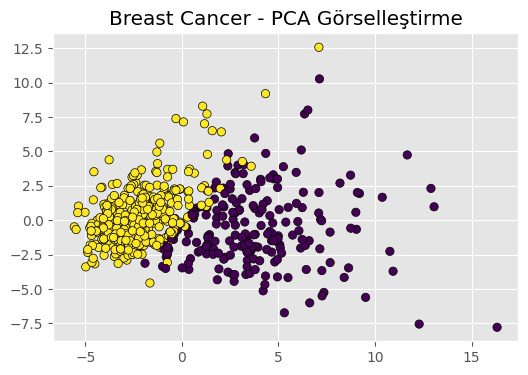

KNN Accuracy: 0.9720


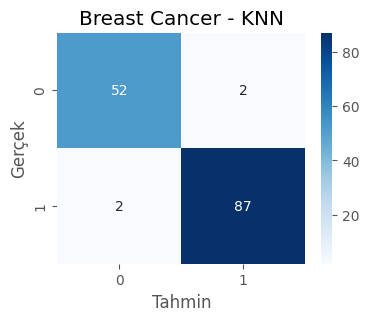

SVM Accuracy: 0.9720


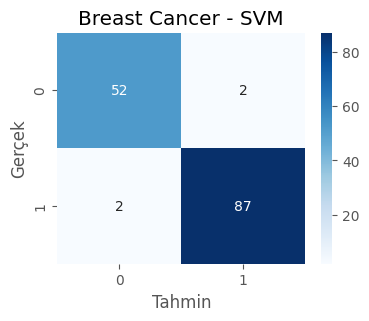

Random Forest Accuracy: 0.9650


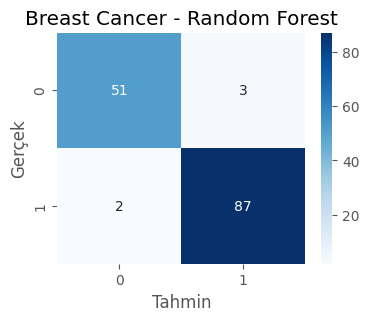


ANALİZ: Wine


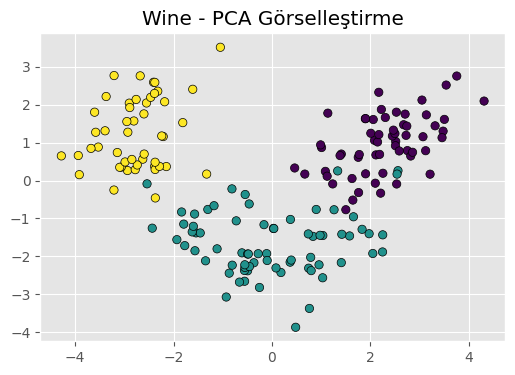

KNN Accuracy: 0.9556


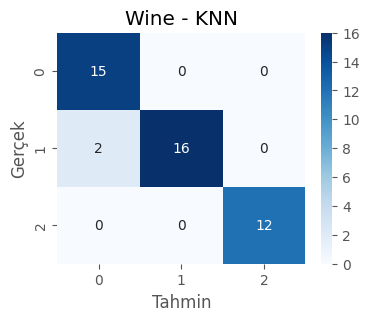

SVM Accuracy: 0.9778


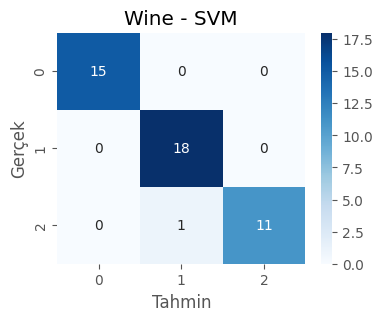

Random Forest Accuracy: 1.0000


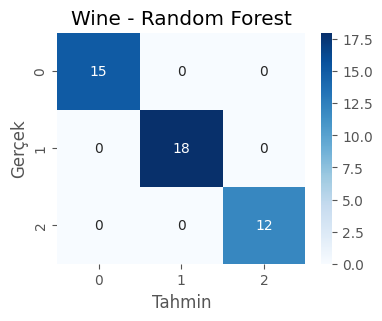


ANALİZ: Moons


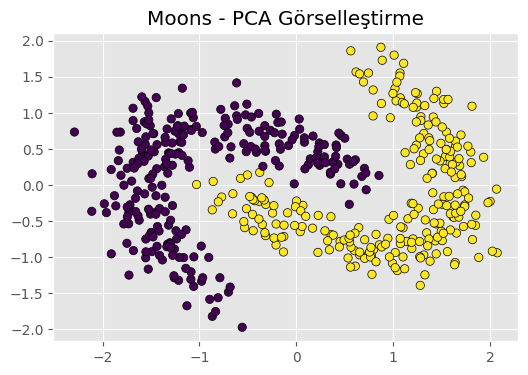

KNN Accuracy: 1.0000


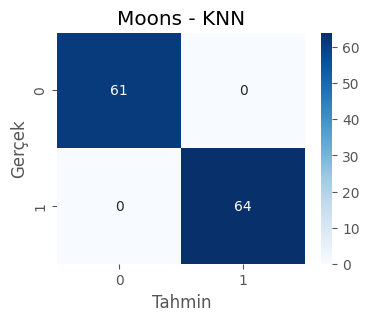

SVM Accuracy: 1.0000


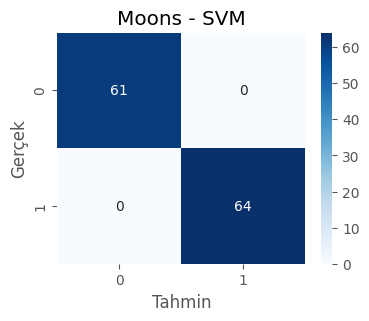

Random Forest Accuracy: 0.9920


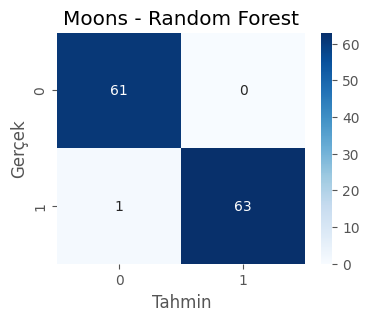

<Figure size 1000x600 with 0 Axes>

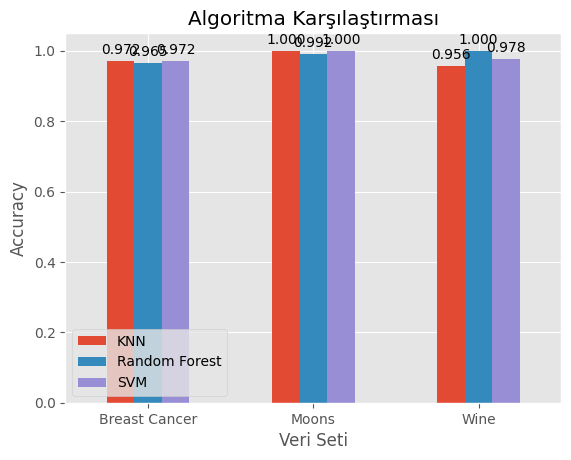


Genel Değerlendirme:
- Random Forest genellikle yüksek performans verir.
- SVM karmaşık verilerde başarılıdır.
- KNN basit ama bazı durumlarda zayıf kalabilir.


In [6]:
# =============================
# 📊 MAKİNE ÖĞRENMESİ KARŞILAŞTIRMA PROJESİ
# =============================

# 🎯 AMAÇ:
# Farklı veri setleri üzerinde KNN, SVM ve Random Forest algoritmalarını karşılaştırmak

# =============================
# 📌 1. KÜTÜPHANELER
# =============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_wine, make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

# =============================
# 📌 2. VERİ SETLERİ
# =============================

# 3 farklı veri seti kullanıyoruz
# - Breast Cancer → Gerçek veri
# - Wine → Sınıflandırma
# - Moons → Lineer olmayan veri

datasets = {
    "Breast Cancer": load_breast_cancer(),
    "Wine": load_wine(),
    "Moons": make_moons(n_samples=500, noise=0.15, random_state=42)
}

# =============================
# 📌 3. HYPERPARAMETER GRID
# =============================

param_grids = {
    "KNN": {
        'n_neighbors': [3, 5, 7, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    "SVM": {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'poly']
    },
    "Random Forest": {
        'n_estimators': [100, 200],
        'random_state': [42]
    }
}

full_results = []

# =============================
# 📌 4. ANALİZ DÖNGÜSÜ
# =============================

for ds_name, ds in datasets.items():
    print(f"\n{'='*40}\nANALİZ: {ds_name}\n{'='*40}")
    
    # Veri ayırma
    X, y = (ds if isinstance(ds, tuple) else (ds.data, ds.target))
    
    # =============================
    # 🎨 PCA GÖRSELLEŞTİRME
    # =============================
    
    pca = PCA(n_components=2)
    X_scaled = StandardScaler().fit_transform(X)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(6,4))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis', edgecolors='k')
    plt.title(f"{ds_name} - PCA Görselleştirme")
    plt.show()
    
    # =============================
    # 🔀 TRAIN - TEST SPLIT
    # =============================
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)
    
    # =============================
    # 🤖 MODEL EĞİTİMİ
    # =============================
    
    for model_name, grid in param_grids.items():
        
        if model_name == "Random Forest":
            model = RandomForestClassifier()
            clf = GridSearchCV(model, grid, cv=5)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
        else:
            model = KNeighborsClassifier() if model_name == "KNN" else SVC()
            clf = GridSearchCV(model, grid, cv=5)
            clf.fit(X_train_sc, y_train)
            y_pred = clf.predict(X_test_sc)
        
        # =============================
        # 📊 ACCURACY
        # =============================
        
        acc = accuracy_score(y_test, y_pred)
        print(f"{model_name} Accuracy: {acc:.4f}")
        
        full_results.append({
            "Veri Seti": ds_name,
            "Algoritma": model_name,
            "Accuracy": acc
        })
        
        # =============================
        # 🔥 CONFUSION MATRIX
        # =============================
        
        cm = confusion_matrix(y_test, y_pred)
        
        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"{ds_name} - {model_name}")
        plt.xlabel("Tahmin")
        plt.ylabel("Gerçek")
        plt.show()

# =============================
# 📌 5. SONUÇLARIN KARŞILAŞTIRILMASI
# =============================

# DataFrame oluştur
results_df = pd.DataFrame(full_results)

pivot_table = results_df.pivot(
    index="Veri Seti",
    columns="Algoritma",
    values="Accuracy"
)

# =============================
# 📊 BAR GRAFİĞİ
# =============================

plt.figure(figsize=(10,6))
ax = pivot_table.plot(kind="bar")

# Değerleri yazdır
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center',
                xytext=(0,8), textcoords='offset points')

plt.title("Algoritma Karşılaştırması")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.legend()
plt.show()

# =============================
# 🏁 SONUÇ
# =============================

print("\nGenel Değerlendirme:")
print("- Random Forest genellikle yüksek performans verir.")
print("- SVM karmaşık verilerde başarılıdır.")
print("- KNN basit ama bazı durumlarda zayıf kalabilir.")
